In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('amazon.csv')

In [ ]:
df.head()

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


In [ ]:
df.shape

(20000, 2)

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("vader_lexicon")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
df.head()

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


In [ ]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [ ]:
analyzer = SentimentIntensityAnalyzer()

In [ ]:
def get_sentiment(text):
  scores = analyzer.polarity_scores(text)
  sentiment = 1 if scores["pos"] > 0 else 0
  return sentiment

In [ ]:
df["sentiment"] = df["reviewText"].apply(get_sentiment)

In [ ]:
df.head()

,reviewText,Positive,sentiment
0,This is a one of the best apps acording to a b...,1,1
1,This is a pretty good version of the game for ...,1,1
2,this is a really cool game. there are a bunch ...,1,1
3,"This is a silly game and can be frustrating, b...",1,1
4,This is a terrific game on any pad. Hrs of fun...,1,1


In [ ]:
scores = analyzer.polarity_scores("one best apps acording bunch people agree bomb")
scores

{'neg': 0.215, 'neu': 0.336, 'pos': 0.45, 'compound': 0.5423}

In [ ]:
from sklearn.metrics import confusion_matrix
result = confusion_matrix(df["Positive"],df["sentiment"])
result

array([[ 1377,  3390],
       [  620, 14613]])

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(df["Positive"],df["sentiment"]))

              precision    recall  f1-score   support

           0       0.69      0.29      0.41      4767
           1       0.81      0.96      0.88     15233

    accuracy                           0.80     20000
   macro avg       0.75      0.62      0.64     20000
weighted avg       0.78      0.80      0.77     20000



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Predicted', ylabel='Actual'>

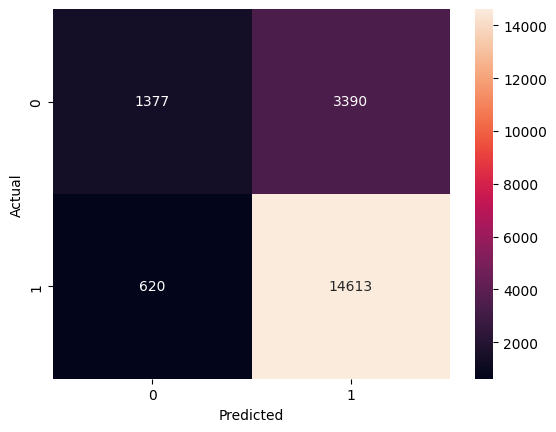

In [ ]:
c_mtrix = pd.crosstab(df["Positive"],df["sentiment"], rownames=["Actual"], colnames=["Predicted"])
c_mtrix
sns.heatmap(c_mtrix, annot=True, fmt=".0f")

In [ ]:
count0 = df["Positive"].value_counts()[0]
count1 = df["Positive"].value_counts()[1]
print("Actual Dataset")
print("0's", count0)
print("1's", count1)


Actual Dataset
0's 4767
1's 15233


In [ ]:
labels = ["0", "1"]
counts = [count0, count1]
plt.figure(figsize=(4,4))
plt.title("Count of 0 and 1 in Training Dataset")
for i, count in enumerate(counts):
    plt.text(i, count, str(count), ha='center', va='bottom', fontsize=10)
plt.bar(labels, counts)
plt.show()

NameError: name 'count0' is not defined